In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rcParams
from pathlib import Path
import numpy as np

# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

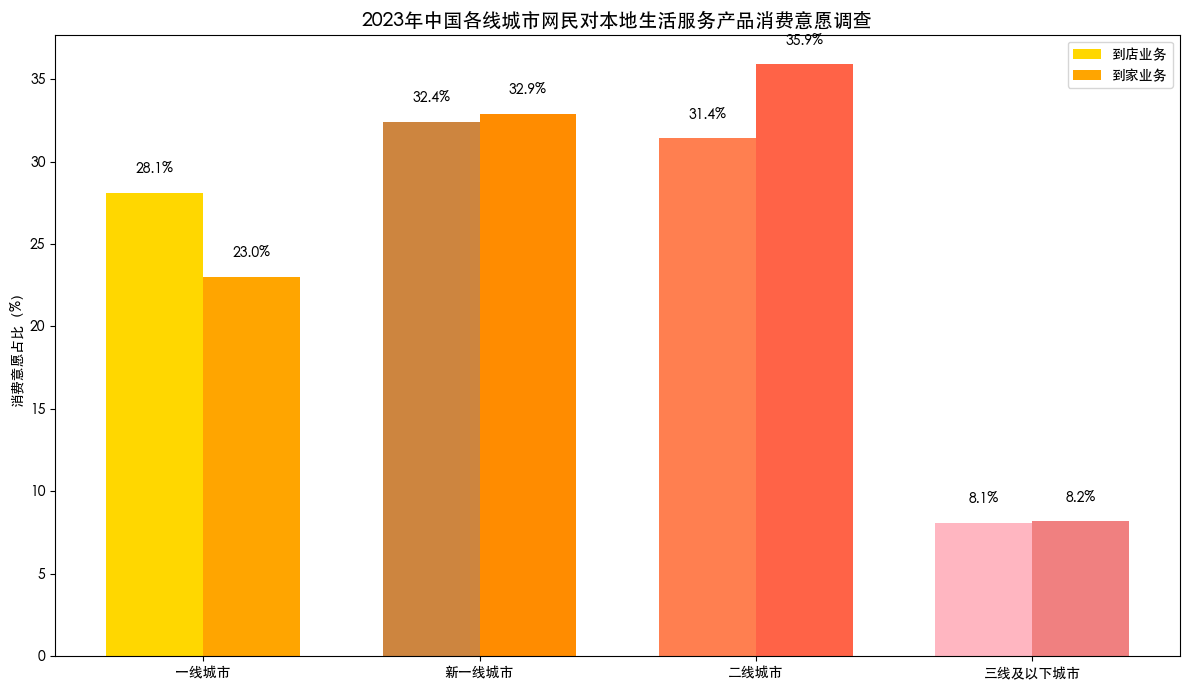

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
# 到店业务各城市类型占比（假设从左到右对应一线城市、新一线城市、二线城市、三线及以下城市 ，根据柱状图视觉判断）
store_service = [28.1, 32.4, 31.4, 8.1]
# 到家业务各城市类型占比（同理对应）
home_service = [23.0, 32.9, 35.9, 8.2]

# 城市类型标签（根据柱状图数量推测）
city_types = ["一线城市", "新一线城市", "二线城市", "三线及以下城市"]
x = np.arange(len(city_types))  # x轴坐标

fig, ax = plt.subplots(figsize=(12, 7))

# 绘制到店业务柱状图（黄色系列）
bar_width = 0.35
ax.bar(x - bar_width/2, store_service, width=bar_width, color=['gold', 'peru', 'coral', 'lightpink'], label='到店业务')
# 绘制到家业务柱状图（橙色系列）
ax.bar(x + bar_width/2, home_service, width=bar_width, color=['orange', 'darkorange', 'tomato', 'lightcoral'], label='到家业务')

ax.set_title('2023年中国各线城市网民对本地生活服务产品消费意愿调查', fontsize=14)
ax.set_ylabel('消费意愿占比（%）')
ax.set_xticks(x)
ax.set_xticklabels(city_types)
ax.legend()

# 添加到店业务数值标注
for i, val in enumerate(store_service):
    ax.text(x[i] - bar_width/2, val + 1, f'{val}%', ha='center', va='bottom', color='black')

# 添加到家业务数值标注
for i, val in enumerate(home_service):
    ax.text(x[i] + bar_width/2, val + 1, f'{val}%', ha='center', va='bottom', color='black')

plt.tight_layout()
plt.show()

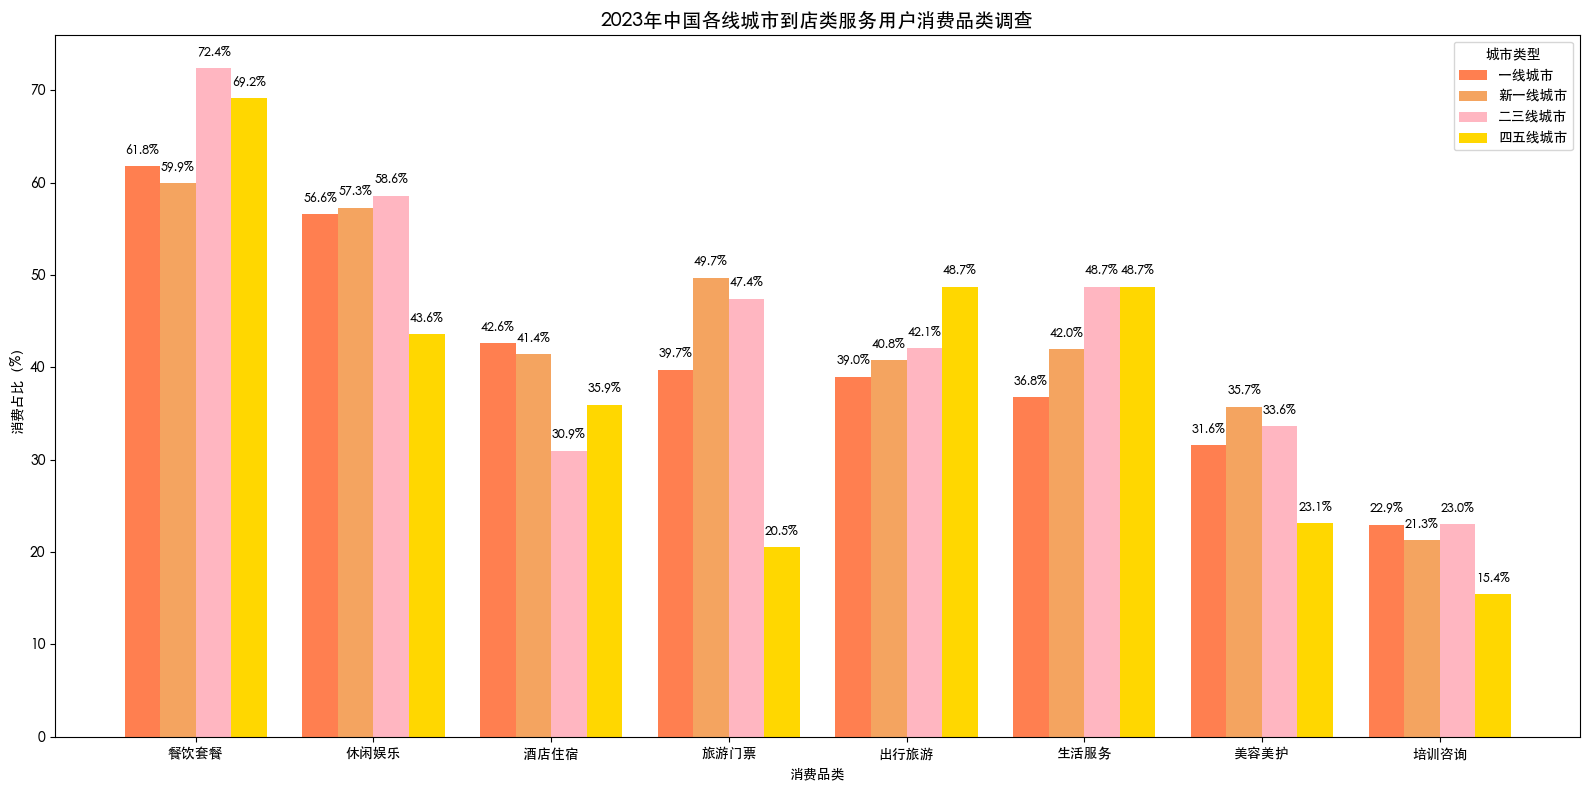

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 数据整理（按品类分组，每个品类包含各线城市的占比）
categories = [
    "餐饮套餐", "休闲娱乐", "酒店住宿", "旅游门票", 
    "出行旅游", "生活服务", "美容美护", "培训咨询"
]
# 各品类下，一线城市、新一线城市、二三线城市、四五线城市的占比（%）
data = {
    "餐饮套餐": [61.8, 59.9, 72.4, 69.2],
    "休闲娱乐": [56.6, 57.3, 58.6, 43.6],
    "酒店住宿": [42.6, 41.4, 30.9, 35.9],
    "旅游门票": [39.7, 49.7, 47.4, 20.5],
    "出行旅游": [39.0, 40.8, 42.1, 48.7],
    "生活服务": [36.8, 42.0, 48.7, 48.7],
    "美容美护": [31.6, 35.7, 33.6, 23.1],
    "培训咨询": [22.9, 21.3, 23.0, 15.4]
}
# 各线城市对应的颜色（与图例一致）
colors = ['coral', 'sandybrown', 'lightpink', 'gold']
# 各线城市标签
city_labels = ["一线城市", "新一线城市", "二三线城市", "四五线城市"]

x = np.arange(len(categories))  # x轴坐标（每个品类对应一个位置）
bar_width = 0.2  # 每个城市类型柱子的宽度

fig, ax = plt.subplots(figsize=(16, 8))

# 循环绘制每个城市类型的柱子
for i in range(4):
    ax.bar(
        x + i * bar_width,  # 控制柱子的x位置，实现分组
        [data[cat][i] for cat in categories],  # 取每个品类下第i个城市类型的占比
        width=bar_width,
        color=colors[i],
        label=city_labels[i]
    )

ax.set_title('2023年中国各线城市到店类服务用户消费品类调查', fontsize=14)
ax.set_ylabel('消费占比（%）')
ax.set_xlabel('消费品类')
ax.set_xticks(x + bar_width * 1.5)  # 调整x轴刻度位置，让标签在分组中间
ax.set_xticklabels(categories)
ax.legend(title='城市类型', loc='upper right')

# 添加数值标注
for i in range(len(categories)):
    for j in range(4):
        value = data[categories[i]][j]
        ax.text(
            x[i] + j * bar_width, 
            value + 1, 
            f'{value}%', 
            ha='center', 
            va='bottom', 
            color='black', 
            fontsize=9
        )

plt.tight_layout()
plt.show()

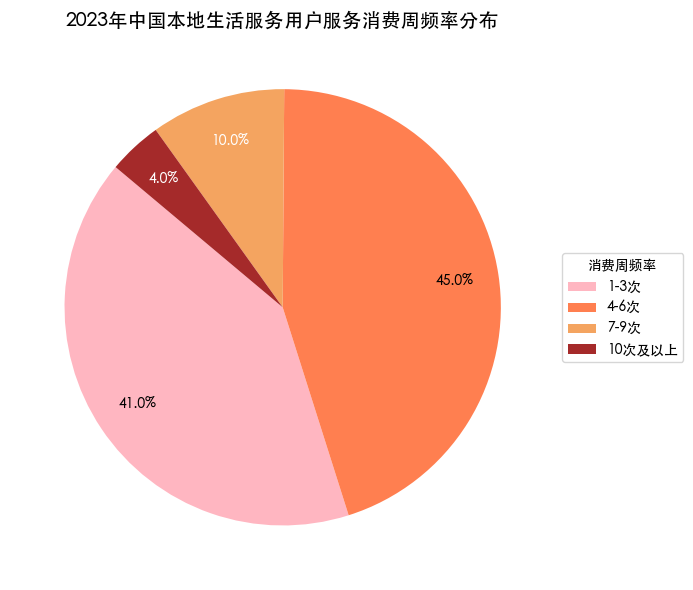

In [6]:
import matplotlib.pyplot as plt

# 数据准备
labels = ["1-3次", "4-6次", "7-9次", "10次及以上"]
sizes = [41.0, 45.0, 10.0, 4.0]  # 占比（%）
colors = ["lightpink", "coral", "sandybrown", "brown"]  # 配色，贴近原图风格

fig, ax = plt.subplots(figsize=(8, 6))

# 绘制饼图
wedges, texts, autotexts = ax.pie(
    sizes, 
    colors=colors, 
    autopct='%1.1f%%', 
    startangle=140,  # 调整起始角度，让饼图分布更合理
    pctdistance=0.8  # 调整标注位置，避免与图例重叠
)

ax.set_title('2023年中国本地生活服务用户服务消费周频率分布', fontsize=14)

# 设置图例（与原图一致的位置和样式）
ax.legend(
    wedges, 
    labels, 
    title="消费周频率", 
    loc="center left", 
    bbox_to_anchor=(1, 0.5)
)

# 优化标注文字颜色（深色切片用白色字，浅色用黑色字）
for autotext in autotexts:
    autotext.set_color('white' if autotext.get_position()[1] > 0.5 else 'black')

plt.tight_layout()
plt.show()

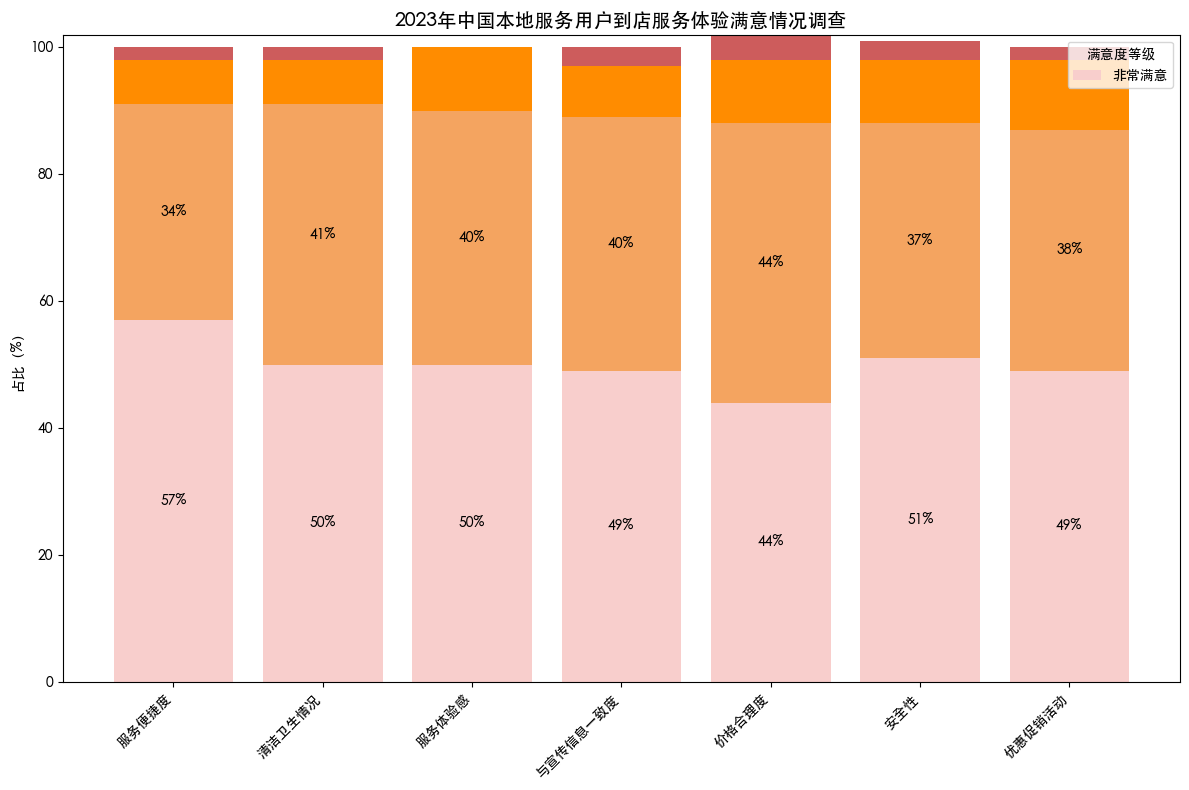

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 数据整理（按指标、满意度等级顺序：非常满意、较满意、一般、较不满意、非常不满意 ）
metrics = [
    "服务便捷度", "清洁卫生情况", "服务体验感", 
    "与宣传信息一致度", "价格合理度", "安全性", "优惠促销活动"
]
# 每个指标下各满意度等级的占比（%）
data = np.array([
    [57, 34, 7, 2, 0],   # 服务便捷度
    [50, 41, 7, 2, 0],   # 清洁卫生情况
    [50, 40, 10, 0, 0],  # 服务体验感
    [49, 40, 8, 3, 0],   # 与宣传信息一致度
    [44, 44, 10, 4, 0],  # 价格合理度
    [51, 37, 10, 3, 0],  # 安全性
    [49, 38, 11, 2, 0]   # 优惠促销活动
])
# 各满意度等级的配色（贴近原图）
colors = ["#f8cecc", "#f4a460", "#ff8c00", "#cd5c5c", "#8b0000"]
# 满意度等级标签
labels = ["非常满意", "较满意", "一般", "较不满意", "非常不满意"]

x = np.arange(len(metrics))  # x轴坐标（每个指标对应一个位置）
bar_width = 0.8  # 柱子宽度，让分段更紧凑

fig, ax = plt.subplots(figsize=(12, 8))

# 绘制分段堆积柱状图
bottom = np.zeros(len(metrics))  # 堆积的起始位置
for i in range(5):
    ax.bar(
        x, 
        data[:, i], 
        width=bar_width, 
        color=colors[i], 
        bottom=bottom, 
        label=labels[i] if i == 0 else ""  # 仅第一个等级显示图例，避免重复
    )
    bottom += data[:, i]  # 更新下一段的起始位置

ax.set_title('2023年中国本地服务用户到店服务体验满意情况调查', fontsize=14)
ax.set_ylabel('占比（%）')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=45, ha='right')
ax.legend(title='满意度等级', loc='upper right')

# 添加数值标注（仅标注“非常满意”和“较满意”，因原图仅显示这两部分数值；若需全标注可扩展循环）
for i in range(len(metrics)):
    # 标注“非常满意”数值
    ax.text(x[i], data[i, 0]/2, f'{data[i, 0]}%', ha='center', va='center', color='black')
    # 标注“较满意”数值
    ax.text(x[i], data[i, 0] + data[i, 1]/2, f'{data[i, 1]}%', ha='center', va='center', color='black')
    # 若需标注“一般”“较不满意”“非常不满意”，可继续添加：
    # ax.text(x[i], data[i, 0]+data[i, 1]+data[i, 2]/2, f'{data[i, 2]}%', ...) 

plt.tight_layout()
plt.show()